# Exploratory data analysis (EDA) — EEG Motor Movement / Imagery

**Purpose:** Discover MNE and inspect one recording from the EEG Motor Movement / Imagery dataset. This notebook is for **exploration only** — not the final training pipeline.

**Dataset:** PhysioNet [EEG Motor Movement/Imagery Database](https://physionet.org/content/eegmmidb/1.0.0/) (MNE can fetch it via `mne.datasets.eegbci`).


### Imports and environment

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import mne
from mne.datasets import eegbci
from mne.io import read_raw_edf

mne.set_log_level("WARNING")
print("MNE version:", mne.__version__)


MNE version: 1.11.0


### Load recording

**We load one file** .edf for subject 1 and run 1.

In [2]:
DATA_DIR = Path("mne_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

subject = 1
runs = [1]

fnames = eegbci.load_data(subject, runs=runs, path=DATA_DIR, update_path=False)
edf_path = Path(fnames[0])
print("File:", edf_path.resolve())

raw = read_raw_edf(edf_path, preload=True, verbose="WARNING")
print(raw)


File: /Users/mehdidesmartin/Documents/Code/42/postCC/total-perspective-vortex/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R01.edf
<RawEDF | S001R01.edf, 64 x 9760 (61.0 s), ~4.8 MiB, data loaded>


/Users/mehdidesmartin/miniconda3/envs/TPV/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Record summary

**The goal** is to confirm sampling rate, length, and channel list before plotting.

In [3]:
print("Sampling frequency (Hz):", raw.info["sfreq"])
print("Duration (s):", raw.times[-1])
print("Number of channels:", len(raw.ch_names))
print("Channel names (first 16):", raw.ch_names[:16])

Sampling frequency (Hz): 160.0
Duration (s): 60.99375
Number of channels: 64
Channel names (first 16): ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.']


## 4. Time series

The goal is to inspect raw voltage over a chosen window and compare channels with MNE’s viewer.

**What we're looking for:** Amplitude in a plausible µV range, neighboring channels moving similarly (spatial correlation), and any wide, simultaneous deflections across many channels (blinks, movement, bad segments).

**What we found:** Raw EEG traces look busy and correlated across nearby channels because they mix brain activity with muscle, environment, and line noise, while large simultaneous bumps or dips on many channels usually point to artifacts like blinks or movement rather than meaningless random noise.

### 4.1 Multichannel traces

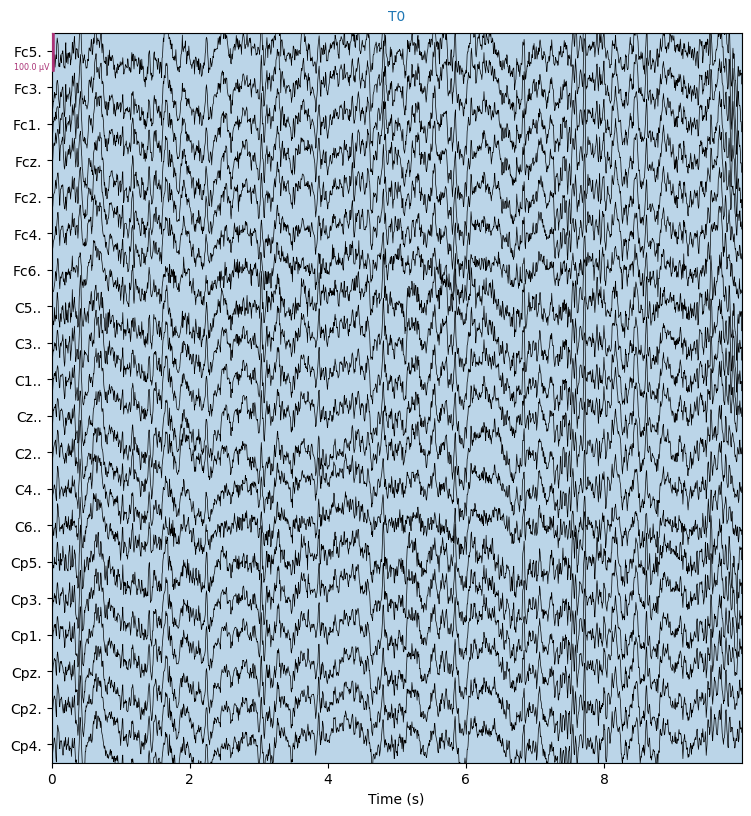

In [4]:
fig = raw.plot(
    duration=10,
    n_channels=20,
    scalings=dict(eeg=50e-6),
    show_scrollbars=False,
)
fig.set_size_inches(12, 6)
plt.show()

### 4.2 Superposed traces

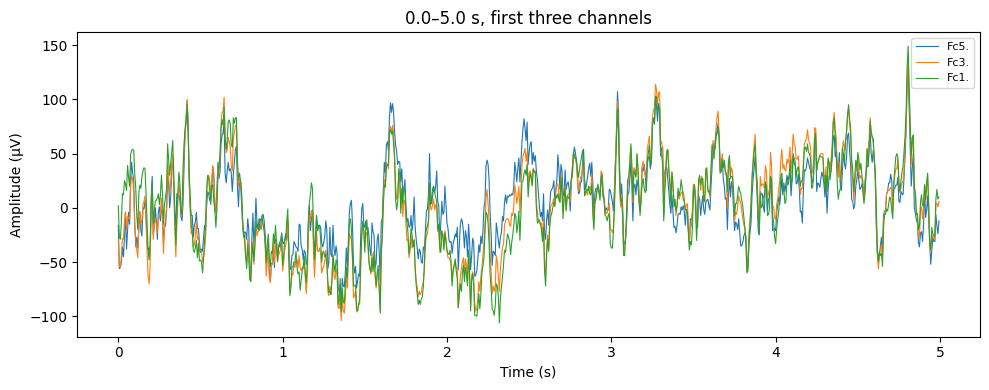

In [5]:
t0, t1 = 0.0, 5.0
data, times = raw.get_data(picks=[0, 1, 2], tmin=t0, tmax=t1, return_times=True)
ch = [raw.ch_names[i] for i in (0, 1, 2)]

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(data.shape[0]):
    ax.plot(times, data[i] * 1e6, label=ch[i], lw=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_title(f"{t0}–{t1} s, first three channels")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Frequency content — Power Spectral Density (PSD)

The goal is to see which frequencies carry power (brain bands vs. narrow interference).

**What we're looking for:** higher power at low frequencies (typical for EEG); a **sharp peak at 50 or 60 Hz** indicates mains / line noise; overall shape informs later filtering (high-pass, notch, band limits).

**What we found:** The PSD shows the expected stronger power at low frequencies and a clear 60 Hz spike from mains interference, with a typical high-frequency roll-off rather than a flat spectrum.

/var/folders/7h/6sg1s7k57y50pnccp69bbnx80000gn/T/ipykernel_85307/2684639470.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = raw.compute_psd(fmax=80).plot()
/Users/mehdidesmartin/miniconda3/envs/TPV/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


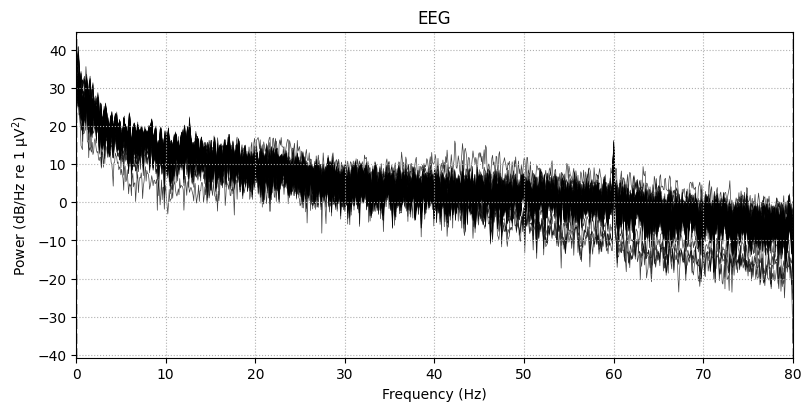

In [6]:
fig = raw.compute_psd(fmax=80).plot()
fig.set_size_inches(8, 4)
plt.show()

## 6. Current source density (CSD)

The goal is to apply **CSD** (spatial transform on the scalp) after montage + average reference, then compare **PSD** of referenced EEG vs CSD — CSD is not PSD; PSD is only the summary we plot.

**What we're looking for:** Reasonable `raw_avg` / `raw_csd` after `compute_current_source_density`; PSD shape, line noise (50/60 Hz), and how spectra differ after CSD.

**What we found:** PSD looks similar in frequency, with the same 60 Hz peak; CSD shifts units and spatial mixing, not the need for a notch filter.

In [7]:
# Prepare for CSD: channel names + positions + average reference (see MNE CSD example)
raw_avg = raw.copy()
eegbci.standardize(raw_avg)
raw_avg.set_montage("standard_1020", match_case=False, on_missing="warn")
raw_avg.set_eeg_reference("average", verbose=False)

raw_csd = mne.preprocessing.compute_current_source_density(raw_avg)
print(raw_avg)
print(raw_csd)


<RawEDF | S001R01.edf, 64 x 9760 (61.0 s), ~4.8 MiB, data loaded>
<RawEDF | S001R01.edf, 64 x 9760 (61.0 s), ~4.8 MiB, data loaded>


### PSD — average reference vs CSD


/Users/mehdidesmartin/miniconda3/envs/TPV/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


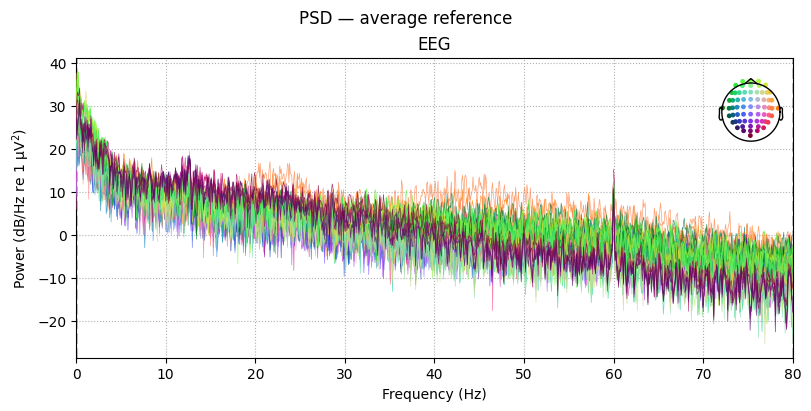

/Users/mehdidesmartin/miniconda3/envs/TPV/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


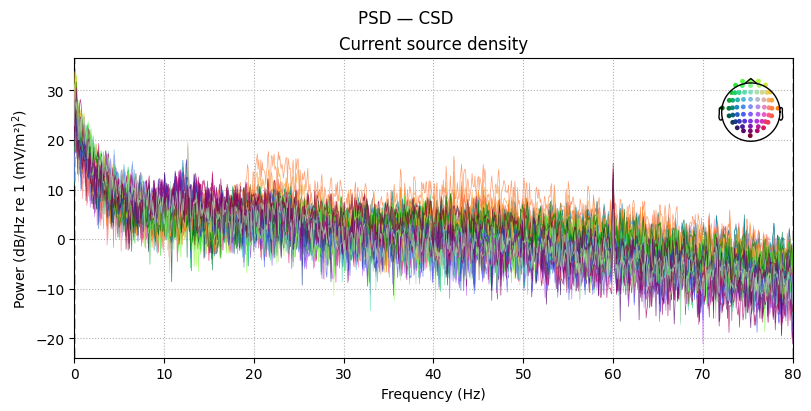

In [8]:
fig = raw_avg.compute_psd(fmax=80).plot()
fig.set_size_inches(8, 4)
plt.suptitle("PSD — average reference")
plt.show()

fig = raw_csd.compute_psd(fmax=80).plot()
fig.set_size_inches(8, 4)
plt.suptitle("PSD — CSD")
plt.show()
